# Блок 2. Классификация на новом датасете

Используется новый датасет `Breast Cancer Wisconsin` из `scikit-learn`.

Сравниваются три алгоритма классификации:

1. Наивный Байес.
2. K ближайших соседей.
3. Машина опорных векторов (SVM).

Цель - по числовым признакам опухоли определить класс: `malignant` или `benign`.


## О датасете Breast Cancer Wisconsin

Датасет содержит `569` наблюдений и `30` числовых признаков.
Целевая переменная бинарная:

- `malignant` - злокачественная опухоль;
- `benign` - доброкачественная опухоль.

Признаки организованы по схеме `10 базовых характеристик x 3 типа оценки`.

Базовые характеристики:

- `radius` - радиус опухоли.
- `texture` - неоднородность текстуры.
- `perimeter` - периметр.
- `area` - площадь.
- `smoothness` - гладкость границы.
- `compactness` - компактность формы.
- `concavity` - выраженность вогнутостей контура.
- `concave points` - количество выраженных вогнутых точек.
- `symmetry` - симметрия.
- `fractal dimension` - фрактальная сложность границы.

Каждая характеристика представлена в трёх вариантах:

- `mean` - среднее значение;
- `error` - стандартная ошибка;
- `worst` - наибольшее наблюдаемое значение.

Например, `mean radius`, `radius error`, `worst radius` относятся к одной и той же физической характеристике,
но отражают разные способы её измерения.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay,
)

cancer = load_breast_cancer()
df_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df_cancer["target"] = cancer.target
df_cancer["target_name"] = df_cancer["target"].map({0: "malignant", 1: "benign"})

print(f"Размер датасета: {df_cancer.shape}")
display(df_cancer.head())


Размер датасета: (569, 32)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,target_name
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


## Первичный анализ и исследование данных

Проверяются:

1. структура таблицы;
2. баланс классов;
3. описательная статистика;
4. наиболее сильные связи признаков с целевой переменной.


Информация о датасете:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  sm

,count
target_name,
benign,357
malignant,212



Описательная статистика:



,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


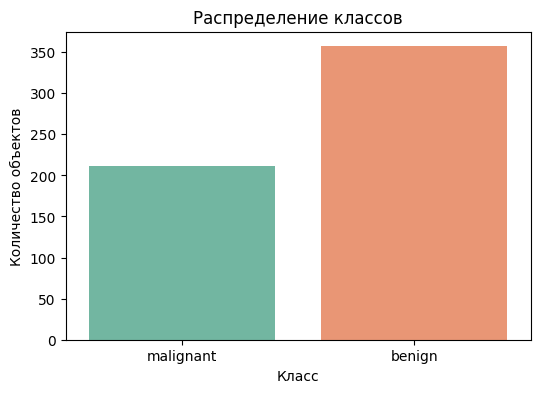

,corr_with_target
worst concave points,-0.793566
worst perimeter,-0.782914
mean concave points,-0.776614
worst radius,-0.776454
mean perimeter,-0.742636
worst area,-0.733825
mean radius,-0.730029
mean area,-0.708984
mean concavity,-0.696360
worst concavity,-0.659610


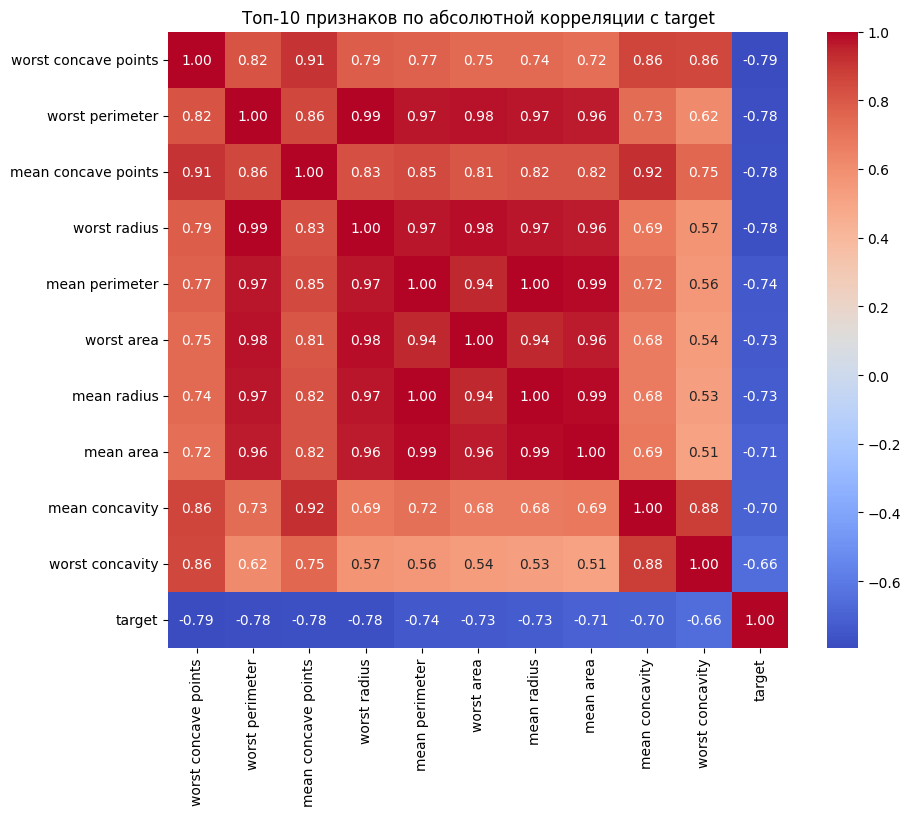

In [2]:
print("Информация о датасете:\n")
df_cancer.info()

print("\nРаспределение классов:\n")
display(df_cancer["target_name"].value_counts().to_frame(name="count"))

print("\nОписательная статистика:\n")
display(df_cancer.drop(columns=["target", "target_name"]).describe())

plt.figure(figsize=(6, 4))
sns.countplot(data=df_cancer, x="target_name", hue="target_name", legend=False, palette="Set2")
plt.title("Распределение классов")
plt.xlabel("Класс")
plt.ylabel("Количество объектов")
plt.show()

corr_with_target = (
    df_cancer.drop(columns=["target_name"])
    .corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

top_corr_features = corr_with_target.head(10).index.tolist()
display(corr_with_target.head(10).to_frame(name="corr_with_target"))

plt.figure(figsize=(10, 8))
sns.heatmap(
    df_cancer[top_corr_features + ["target"]].corr(numeric_only=True),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Топ-10 признаков по абсолютной корреляции с target")
plt.show()


## Подготовка данных

Формируются признаки и целевая переменная.
Далее данные делятся на train/test с сохранением пропорций классов.
После разбиения выполняется стандартизация признаков.

Стандартизация особенно важна для KNN и SVM, поскольку обе модели чувствительны к масштабу признаков.


In [3]:
X = df_cancer.drop(columns=["target", "target_name"])
y = df_cancer["target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер train: {X_train.shape}")
print(f"Размер test: {X_test.shape}")


Размер train: (455, 30)
Размер test: (114, 30)


## Обучение моделей

Обучаются три модели:

- `GaussianNB` - наивный байесовский классификатор;
- `KNeighborsClassifier` - метод ближайших соседей;
- `SVC` - метод опорных векторов.

Для KNN и SVM дополнительно подбираются гиперпараметры через `GridSearchCV`.


In [4]:
model_nb = GaussianNB()
model_nb.fit(X_train_scaled, y_train)

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid={
        "n_neighbors": [3, 5, 7, 9, 11],
        "weights": ["uniform", "distance"],
        "metric": ["euclidean", "manhattan"],
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
knn_grid.fit(X_train_scaled, y_train)
model_knn = knn_grid.best_estimator_

svm_grid = GridSearchCV(
    SVC(probability=True),
    param_grid={
        "C": [0.1, 1, 10],
        "kernel": ["linear", "rbf"],
        "gamma": ["scale", "auto"],
    },
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
svm_grid.fit(X_train_scaled, y_train)
model_svm = svm_grid.best_estimator_

print("Лучшие параметры KNN:")
print(knn_grid.best_params_)
print("\nЛучшие параметры SVM:")
print(svm_grid.best_params_)


Лучшие параметры KNN:
{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}

Лучшие параметры SVM:
{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


## Метрики, матрицы ошибок и ROC-кривые

Для каждой модели рассчитываются:

- `accuracy`;
- `precision`;
- `recall`;
- `f1-score`;
- `ROC-AUC`.

Как читать confusion matrix:

- строки соответствуют реальным классам;
- столбцы соответствуют предсказанным классам;
- главная диагональ содержит правильные классификации;
- значения вне диагонали соответствуют ошибкам модели.

ROC-кривая показывает, как меняется соотношение между чувствительностью и ложноположительными срабатываниями.
Чем ближе кривая к левому верхнему углу и чем больше `ROC-AUC`, тем лучше модель отделяет классы.


Сравнение моделей:


,Модель,Accuracy,Precision,Recall,F1,ROC_AUC
2,SVM,0.982456,0.986111,0.986111,0.986111,0.993717
1,KNN,0.982456,0.972973,1.000000,0.986301,0.983466
0,Naive Bayes,0.929825,0.944444,0.944444,0.944444,0.986772


Naive Bayes:

              precision    recall  f1-score   support

   malignant       0.90      0.90      0.90        42
      benign       0.94      0.94      0.94        72

    accuracy                           0.93       114
   macro avg       0.92      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114

KNN:

              precision    recall  f1-score   support

   malignant       1.00      0.95      0.98        42
      benign       0.97      1.00      0.99        72

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

SVM:

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98     

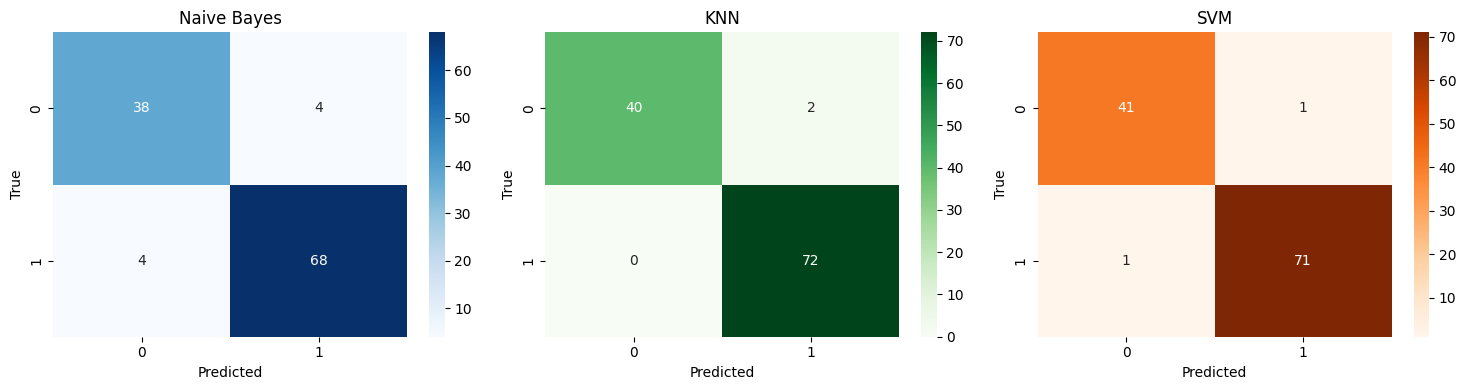

<Figure size 700x600 with 0 Axes>

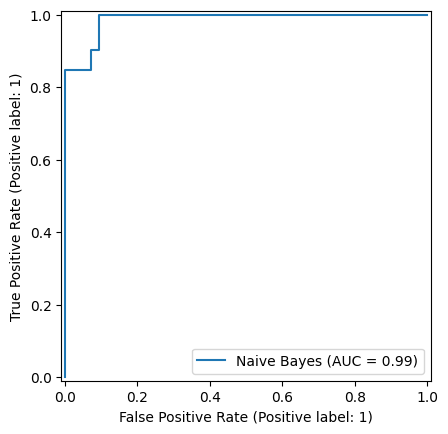

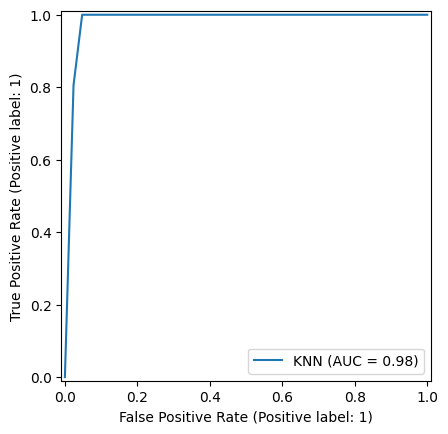

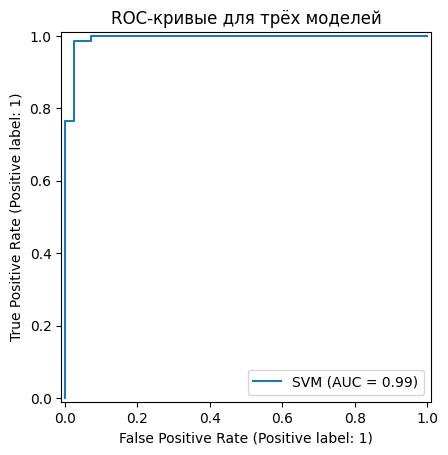

In [5]:
y_pred_nb = model_nb.predict(X_test_scaled)
y_pred_knn = model_knn.predict(X_test_scaled)
y_pred_svm = model_svm.predict(X_test_scaled)

y_proba_nb = model_nb.predict_proba(X_test_scaled)[:, 1]
y_proba_knn = model_knn.predict_proba(X_test_scaled)[:, 1]
y_proba_svm = model_svm.predict_proba(X_test_scaled)[:, 1]

results_df = pd.DataFrame(
    {
        "Модель": ["Naive Bayes", "KNN", "SVM"],
        "Accuracy": [
            accuracy_score(y_test, y_pred_nb),
            accuracy_score(y_test, y_pred_knn),
            accuracy_score(y_test, y_pred_svm),
        ],
        "Precision": [
            precision_score(y_test, y_pred_nb),
            precision_score(y_test, y_pred_knn),
            precision_score(y_test, y_pred_svm),
        ],
        "Recall": [
            recall_score(y_test, y_pred_nb),
            recall_score(y_test, y_pred_knn),
            recall_score(y_test, y_pred_svm),
        ],
        "F1": [
            f1_score(y_test, y_pred_nb),
            f1_score(y_test, y_pred_knn),
            f1_score(y_test, y_pred_svm),
        ],
        "ROC_AUC": [
            roc_auc_score(y_test, y_proba_nb),
            roc_auc_score(y_test, y_proba_knn),
            roc_auc_score(y_test, y_proba_svm),
        ],
    }
).sort_values(by=["Accuracy", "ROC_AUC"], ascending=False)

print("Сравнение моделей:")
display(results_df)

print("Naive Bayes:\n")
print(classification_report(y_test, y_pred_nb, target_names=cancer.target_names))
print("KNN:\n")
print(classification_report(y_test, y_pred_knn, target_names=cancer.target_names))
print("SVM:\n")
print(classification_report(y_test, y_pred_svm, target_names=cancer.target_names))

cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_svm = confusion_matrix(y_test, y_pred_svm)

fig, axs = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", ax=axs[0])
axs[0].set_title("Naive Bayes")
axs[0].set_xlabel("Predicted")
axs[0].set_ylabel("True")

sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Greens", ax=axs[1])
axs[1].set_title("KNN")
axs[1].set_xlabel("Predicted")
axs[1].set_ylabel("True")

sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Oranges", ax=axs[2])
axs[2].set_title("SVM")
axs[2].set_xlabel("Predicted")
axs[2].set_ylabel("True")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_nb, name="Naive Bayes")
RocCurveDisplay.from_predictions(y_test, y_proba_knn, name="KNN")
RocCurveDisplay.from_predictions(y_test, y_proba_svm, name="SVM")
plt.title("ROC-кривые для трёх моделей")
plt.show()


## Вывод

Исследование проведено на новом датасете `Breast Cancer Wisconsin`.
Итоговое сравнение моделей выполняется по таблице метрик выше.

Интерпретация результатов:

- более высокий `accuracy` означает большую долю правильных ответов;
- более высокий `recall` особенно важен для класса `malignant`, если нужно уменьшить число пропусков;
- более высокий `ROC-AUC` означает лучшее разделение классов по вероятностям;
- более плотная диагональ в confusion matrix означает меньшее число ошибок классификации.

Модель с наилучшим сочетанием этих показателей считается наиболее подходящей для данного датасета.
